# 07 - Interpretation

What the model leans on. I use permutation importance on the held-out sessions, which measures how much the test error grows when a feature's values are shuffled, so it reflects what the model actually relies on rather than how the trees were built. I report it in RMSE units and cross-check the direction of each effect against the linear model's standardised coefficients.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from src.data_prep import load_raw, clean, split_by_profile
from src.features import make_preprocessor
from src.model import build_model
from src.config import FEATURES

df = clean(load_raw())
X_train, X_test, y_train, y_test, groups_train = split_by_profile(df)
model = build_model().fit(X_train, y_train)

## Permutation importance

ambient        4.422
u_d            4.317
coolant        3.321
motor_speed    2.583
i_d            1.890
i_q            1.036
u_q            0.667
dtype: float64

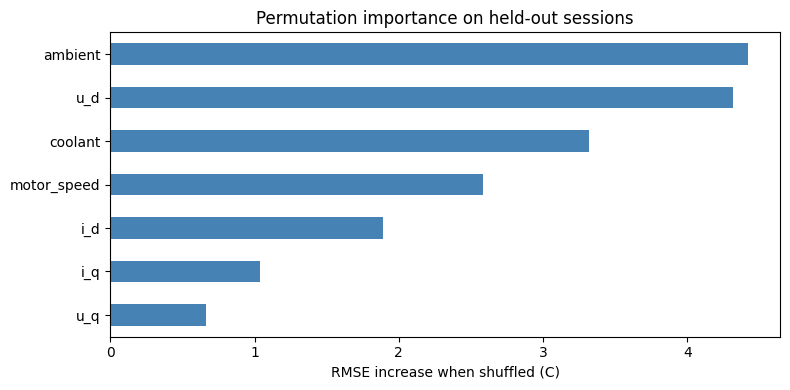

In [2]:
# fixed-seed test subsample keeps the repeated shuffling quick
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test), 50000, replace=False)

pi = permutation_importance(
    model, X_test.iloc[idx], y_test.iloc[idx],
    n_repeats=5, random_state=42,
    scoring="neg_root_mean_squared_error", n_jobs=-1)
importance = pd.Series(pi.importances_mean, index=FEATURES).sort_values()

ax = importance.plot.barh(figsize=(8, 4), color="steelblue")
ax.set_xlabel("RMSE increase when shuffled (C)")
ax.set_title("Permutation importance on held-out sessions")
ax.figure.tight_layout()
ax.figure.savefig("../reports/figures/permutation_importance.png", dpi=120, bbox_inches="tight")
importance.sort_values(ascending=False).round(3)

Ambient temperature and the d-axis voltage are the model's two biggest levers, with coolant and motor speed close behind, and the q-axis terms contributing least. No single feature carries the prediction, which fits the moderate correlations from the EDA: the magnet temperature is a blend of how warm the surroundings are, how hard the motor is being driven electrically, and how fast it's turning.

One caveat to keep in mind: ambient and coolant move together to some extent, and permutation importance can understate a feature whose information is also available through a correlated one, since the model leans on the partner when the values are shuffled. So the ranking is about each feature's unique contribution to this particular model, not a standalone physical ranking.

## Direction of effect, against the linear model

In [3]:
linear = Pipeline([
    ("pre", make_preprocessor(scale=True)),
    ("model", LinearRegression()),
]).fit(X_train, y_train)

pd.DataFrame({
    "perm_importance": pi.importances_mean,
    "linear_coef": linear["model"].coef_,
}, index=FEATURES).sort_values("perm_importance", ascending=False).round(3)

,perm_importance,linear_coef
ambient,4.422,6.559
u_d,4.317,-4.634
coolant,3.321,5.785
motor_speed,2.583,7.157
i_d,1.890,-3.597
i_q,1.036,-2.809
u_q,0.667,-4.068


## What drives the magnet temperature

Both views agree on the leading drivers, ambient, coolant, motor speed and the d-axis voltage, and the signs are physically sensible: hotter surroundings, faster operation and a warmer coolant loop go with a hotter magnet, while the voltage and current components carry negative weight. They disagree on the exact order, the linear model leans hardest on motor speed, the gradient booster on ambient and the d-axis voltage. That is the expected difference between the two measures: a standardised coefficient is the marginal linear effect of a feature, whereas permutation importance is the unique contribution a feature makes to the fitted model once correlations with the others are accounted for.

The headline for the report is that the prediction is genuinely multivariate. There's no single dominant sensor, the model combines ambient and coolant temperatures, the electrical drive through the voltage and current components, and motor speed, into an estimate of the magnet temperature, and that mix lines up with how a motor actually heats up.